In [ ]:
from neurons.lif_neuron import LIFNeuronPopulation
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

: 

In [19]:
from network_samples.reservoir import get_random_reservoir_n_29, get_biased_reservoir_n_29, get_spike_chain

1000it [00:38, 25.99it/s]


Simulation finished.


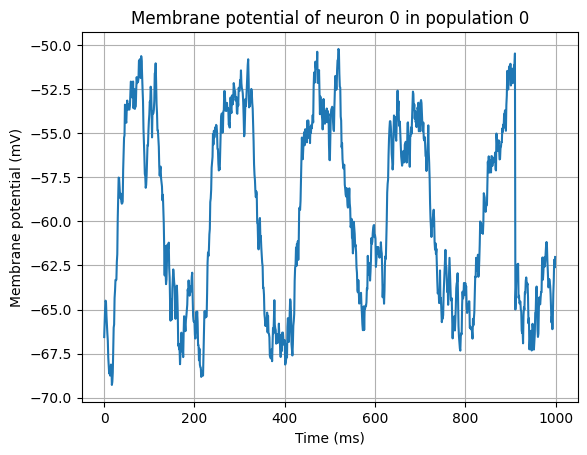

In [30]:

# Network parameters
num_pops = 29
T = 1000
neurons_per_pop = 256
dt = 1.0

populations, connection_matrices = get_spike_chain(num_pops=num_pops, neurons_per_pop = neurons_per_pop, dt = dt)
time = np.arange(0, T, dt)

# External input: shape (time, num_pops, neurons_per_pop)
I_ext = np.zeros((len(time), num_pops, neurons_per_pop))

# Example: provide a pulse input to each population at different time windows, add small variation per neuron
for p in range(num_pops):
    start = 20 #+ p*2
    base_current = 12
    noise_level = 0.4
    interval = 100
    for n in range(neurons_per_pop):
        for t_start in range(start, len(time), interval * 2):
            end = t_start + interval

            I_ext[t_start:end, p, n] = base_current + np.random.uniform(-noise_level, noise_level)

# Prepare recording arrays
V_trace = np.zeros((len(time), num_pops, neurons_per_pop))
spikes_record = np.zeros((len(time), num_pops, neurons_per_pop), dtype=bool)

# Initialize spike state for previous step (per population)
S_prev = np.zeros((num_pops, neurons_per_pop))

for t_i, t in tqdm(enumerate(time)):
    # Compute inputs to each population from all populations
    inputs = np.zeros((num_pops, neurons_per_pop))
    for target_pop in range(num_pops):
        # Sum over all source populations
        for source_pop in range(num_pops):
            inputs[target_pop] += connection_matrices[target_pop, source_pop] @ S_prev[source_pop]
    
    # Add external input
    total_input = inputs + I_ext[t_i]
    
    # Step populations independently
    for p in range(num_pops):
        spikes = populations[p].step(total_input[p], t)
        V_trace[t_i, p] = populations[p].V
        spikes_record[t_i, p] = spikes
        S_prev[p] = spikes

print("Simulation finished.")

# Example plot: membrane potential of first neuron in first population
plt.plot(time, V_trace[:, 0, 0])
plt.title("Membrane potential of neuron 0 in population 0")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.grid(True)
plt.show()

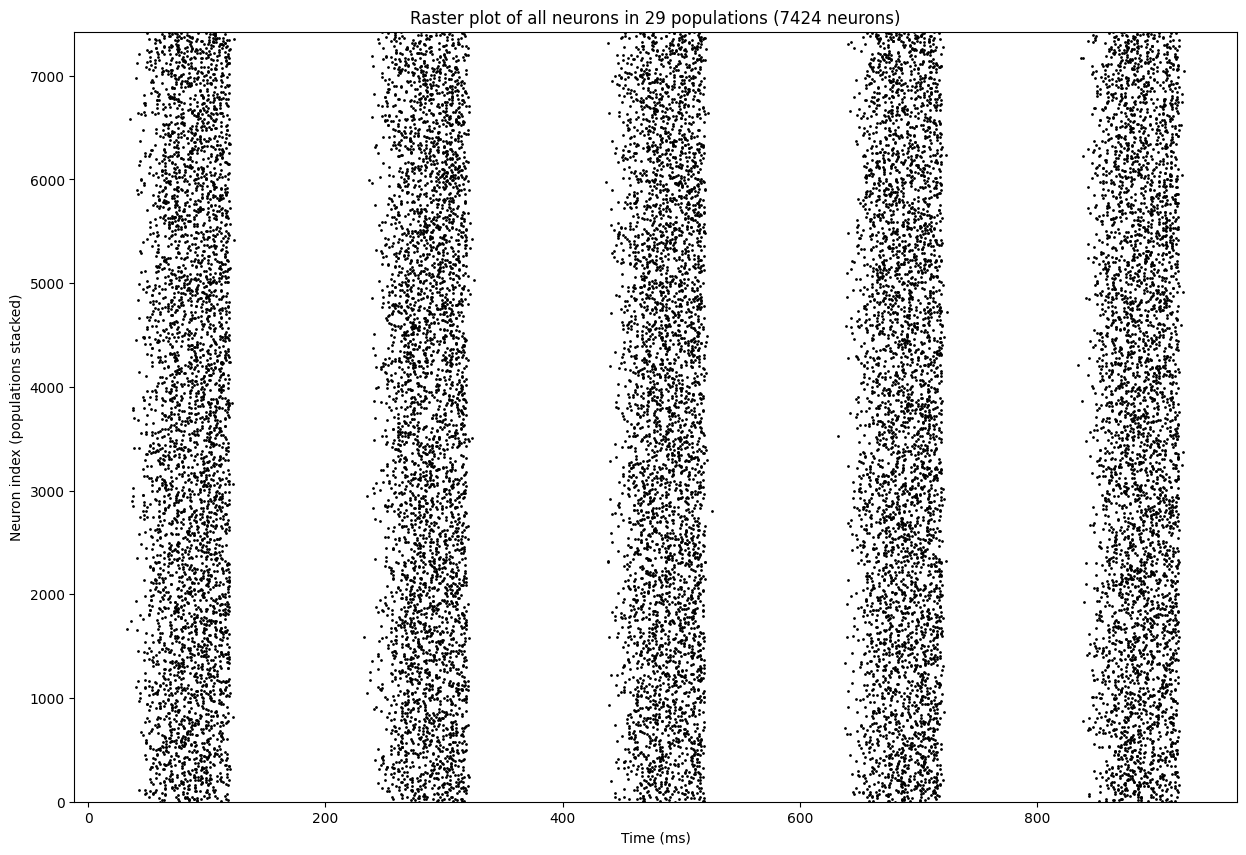

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten spike times into one list of (spike_time, global_neuron_index)

spike_times_all = []
neuron_indices_all = []

for pop_idx in range(num_pops):
    for neuron_idx in range(neurons_per_pop):
        # Get spike times for this neuron
        stimes = populations[pop_idx].spike_times[neuron_idx]
        # Global neuron ID (pop * neurons_per_pop + neuron)
        global_id = pop_idx * neurons_per_pop + neuron_idx
        spike_times_all.extend(stimes)
        neuron_indices_all.extend([global_id] * len(stimes))

spike_times_all = np.array(spike_times_all)
neuron_indices_all = np.array(neuron_indices_all)

# Plot raster
plt.figure(figsize=(15, 10))
plt.scatter(spike_times_all, neuron_indices_all, s=1, color='black')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index (populations stacked)')
plt.title('Raster plot of all neurons in 29 populations (7424 neurons)')
plt.ylim([-1, num_pops*neurons_per_pop])
plt.show()


In [41]:
np.savez("./data/spike_chain_iter1000_record", neuron_indices_all=neuron_indices_all, spike_times_all=spike_times_all)

In [32]:
from utils import evaluate_partitioning

In [33]:
J = np.random.rand(num_pops, num_pops)
# Make symmetric if functional coupling is symmetric
J = (J + J.T) / 2

In [34]:
import numpy as np
import matplotlib.pyplot as plt

num_trials = 1000  # number of random assignments to test
num_pops = len(populations)
num_chips = 3
cores_per_chip = 4
num_cores = num_chips * cores_per_chip

all_metrics = []  # list to store all metrics dict per trial

for trial in range(num_trials):
    chip_ids = np.random.randint(0, num_chips, size=num_pops)
    core_ids = np.random.randint(0, cores_per_chip, size=num_pops)
    partitioning = np.column_stack((chip_ids, core_ids))
    random_assignments = chip_ids * cores_per_chip + core_ids

    metrics = evaluate_partitioning(
        populations,
        random_assignments,
        J,
        neuron_update_cost=1.0,
        spiking_cost=5.0,
        total_frequency_budget=80.0,
        f_min=2.0,
        f_max=12.0,
        comm_bandwidth_matrix=None,
        power_per_freq_unit=1.5,
    )

    all_metrics.append(metrics)

    print(f"Trial {trial + 1} Metrics:")
    for k, v in metrics.items():
        if isinstance(v, (float, int)):
            print(f"  {k}: {v:.4f}")
        else:
            if hasattr(v, 'shape'):
                print(f"  {k}: array shape {v.shape}, first 5: {v[:5]}")
            else:
                print(f"  {k}: {v}")
    print("\n")


Trial 1 Metrics:
  communication_cost: 371.4046
  intra_partition_coherence: 0.4629
  load_balance_cv: 0.6906
  cross_partition_interference: 0.0000
  total_simulation_time: 2113.5000
  power_estimate: 480.2680
  resource_utilization_efficiency: 1439.2448
  frequency_allocation: array shape (12,), first 5: [2.67371283 5.61931568 5.51209145 2.62775959 8.37727612]
  time_cost_per_core: array shape (12,), first 5: [1305.675 1305.675 1305.675 1305.675 1305.675]
  workload_per_core: array shape (12,), first 5: [ 3491.  7337.  7197.  3431. 10938.]
  spike_count_per_core: array shape (12,), first 5: [ 647. 1365. 1337.  635. 2034.]


Trial 2 Metrics:
  communication_cost: 376.5252
  intra_partition_coherence: 0.5044
  load_balance_cv: 0.4326
  cross_partition_interference: 0.0000
  total_simulation_time: 1305.6750
  power_estimate: 496.5252
  resource_utilization_efficiency: 1305.6750
  frequency_allocation: array shape (11,), first 5: [8.33898175 8.19729259 2.815402   8.21261034 2.78859594]
 

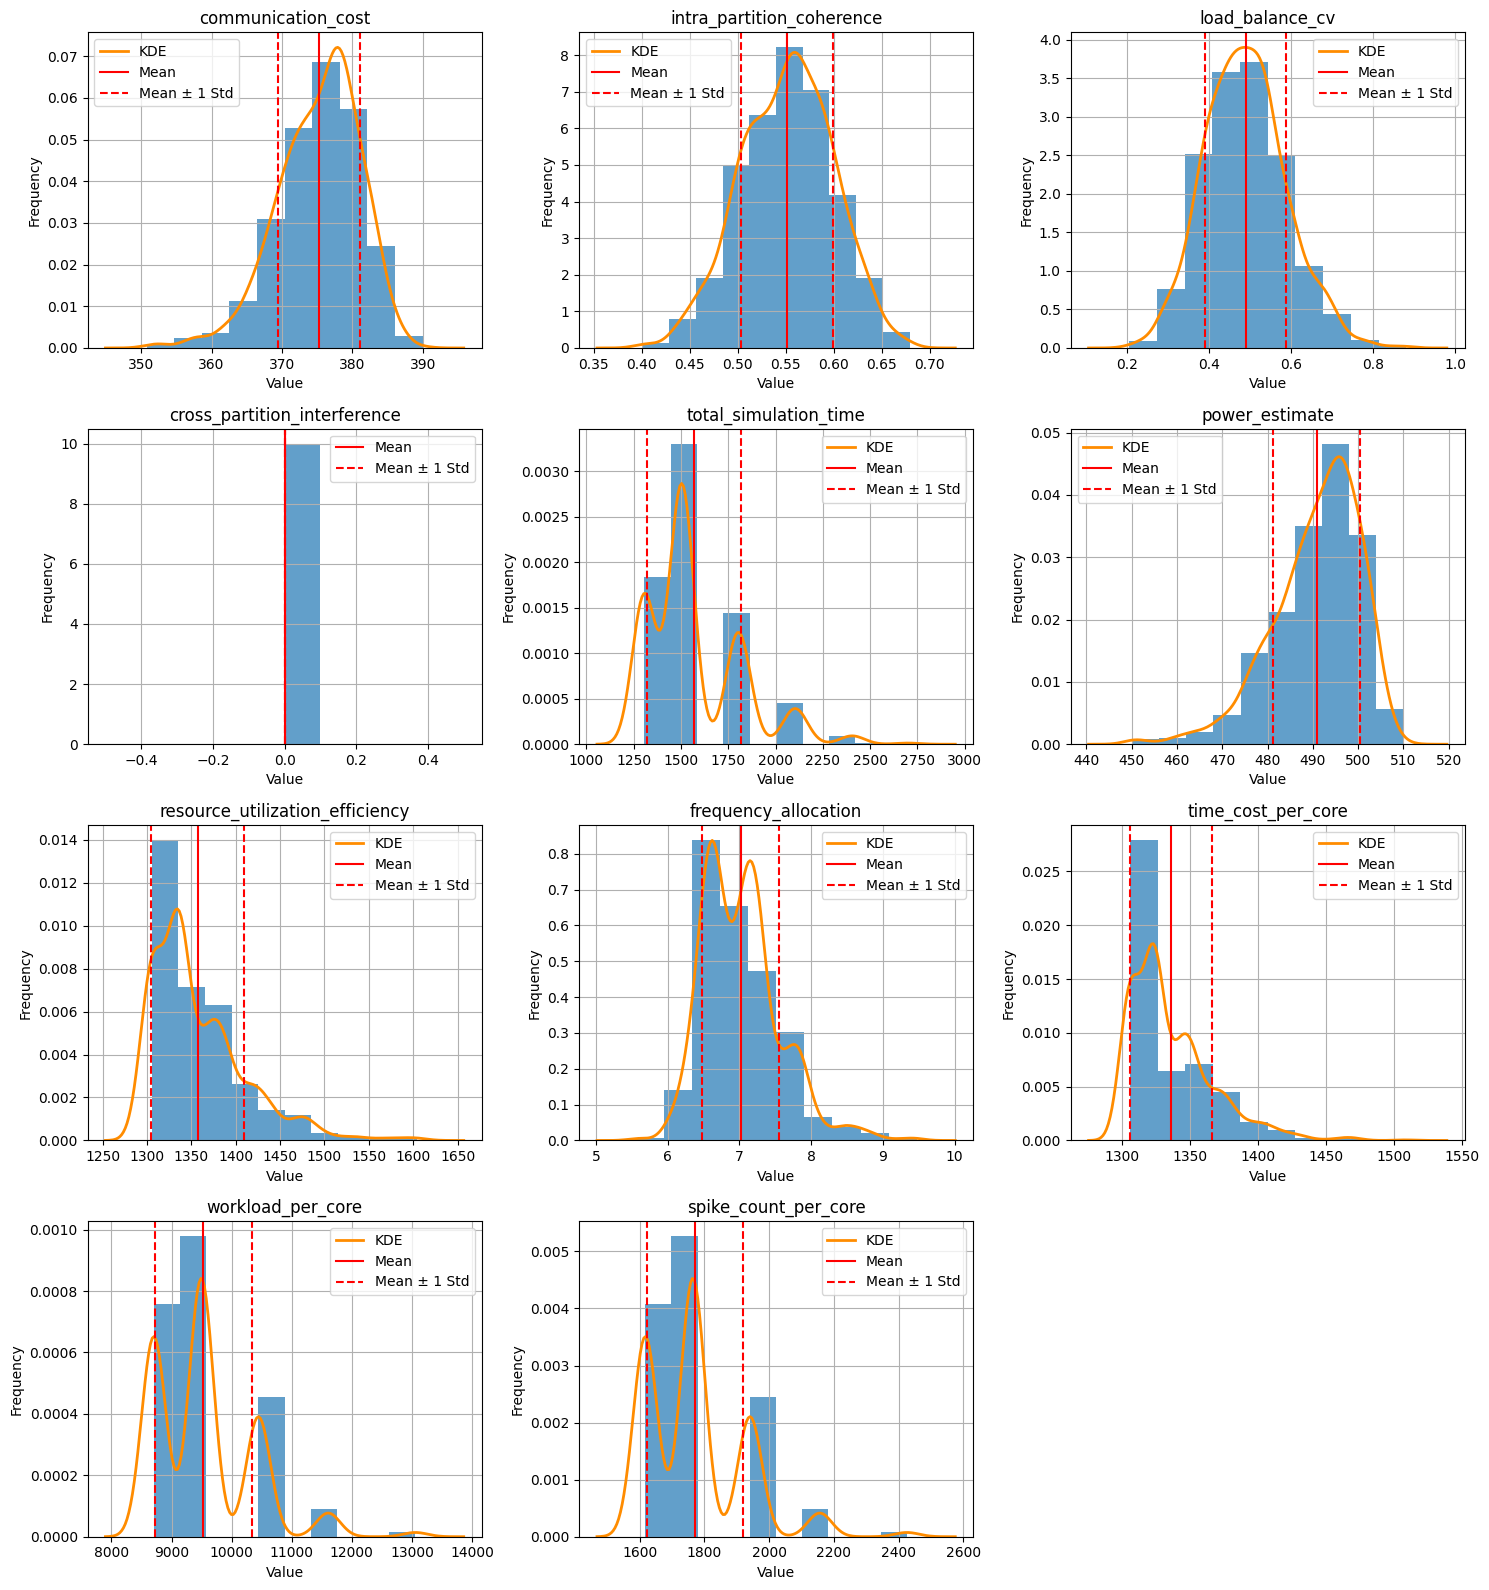

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

num_trials = 1000  # number of random assignments to test

# After you run the trials and have all_metrics collected as before...

# First, identify all metric keys
metric_keys = all_metrics[0].keys()

# Prepare a dict to hold reduced stats per metric across trials
reduced_metrics = {k: [] for k in metric_keys}

for m in all_metrics:
    for k, v in m.items():
        # If scalar, just append
        if isinstance(v, (int, float)):
            reduced_metrics[k].append(v)
        else:
            # If numpy array or list, convert to numpy array and take mean
            arr = np.array(v)
            reduced_metrics[k].append(arr.mean())

# Plot all metrics as histograms
import numpy as np
import matplotlib.pyplot as plt

num_metrics = len(metric_keys)
cols = 3
rows = (num_metrics + cols - 1) // cols

plt.figure(figsize=(5 * cols, 4 * rows))

for i, k in enumerate(metric_keys, 1):
    data = np.array(reduced_metrics[k])
    mean_val = data.mean()
    std_val = data.std()

    plt.subplot(rows, cols, i)
    plt.hist(data, color='tab:blue', alpha=0.7, density=True)
    
    if std_val > 1e-8:
        try:
            kde = gaussian_kde(data)
            x_range = np.linspace(data.min() - std_val, data.max() + std_val, 200)
            plt.plot(x_range, kde(x_range), color='darkorange', lw=2, label='KDE')
        except np.linalg.LinAlgError:
            # In case of unexpected numerical issues, skip KDE
            pass

    
    plt.axvline(mean_val, color='red', linestyle='-', label='Mean')
    plt.axvline(mean_val - std_val, color='red', linestyle='--', label='Mean ± 1 Std')
    plt.axvline(mean_val + std_val, color='red', linestyle='--')
    plt.title(k)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()
